# 📊 第 99 课 · 昇腾推理性能调优:吞吐、时延与 profiling

> TTFT/TPOT/吞吐 · msprof profiling · 优化方法论 · 与 vLLM 调优对照

**章节**: 第 11 章 · 华为昇腾与 MindSpore 生态

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 回顾并熟练使用三大指标:TTFT、TPOT、吞吐(衔接第 50 课)
- 认识昇腾 profiling 工具链:msprof、Ascend Insight Toolkit
- 掌握昇腾调优方法论:先量后改、逐项开关、复测对比
- 理解关键优化:图模式 vs eager、算子融合、动态 shape、KV 量化、TP 并行
- 建立 vLLM(GPU)与昇腾/MindIE 调优参数的对照表
- 用 torch 模拟并发吞吐扫描与 profiling 瀑布,配 App 仪表盘

## 📑 本课目录

1. **直觉:高峰餐厅排班** — 并发、等待、出菜 —— 性能调优就是排班
2. **三大指标回顾** — TTFT / TPOT / 吞吐,以及 50 课的沉淀
3. **昇腾 profiling 工具** — msprof 与 Ascend Insight Toolkit
4. **并发吞吐扫描(动手)** — torch 模拟,找甜蜜点
5. **profiling 瀑布图** — 算子耗时分解与优化前后对比
6. **调优方法论** — 先量后改 · 逐项开关 · 复测
7. **vLLM ↔ 昇腾参数对照** — GPU 经验如何平移到昇腾
8. **配套 App** — app_99_ascend_perf.py:性能仪表盘

## 🔗 参考资料

- [昇腾性能分析(Ascend Insight)](https://www.hiascend.com/document)
- [MindIE 推理引擎](https://www.hiascend.com/software/mindie)
- [vLLM 性能文档(对照)](https://docs.vllm.ai/en/latest/performance/overview.html)
- [vLLM-Ascend](https://github.com/vllm-project/vllm-ascend)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 OMP 库冲突(Windows)
import time, math
import numpy as np
import pandas as pd
import torch

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
print("本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。")

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。


## 1️⃣ 直觉:高峰餐厅排班 🍽️

一家餐厅在高峰期同时接待很多桌(并发请求),经理要回答三个问题:

1. **首菜多久上**(TTFT):客人等第一道菜的时间 —— 对应 prefill 阶段;
2. **后续每道菜多久**(TPOT):后续每字生成的时间 —— 对应 decode 阶段;
3. **每小时能翻多少台**(吞吐):单位时间服务完的 token 总数。

经理的手段(调优)无非:**让后厨少空转(图模式/融合)、让备料更高效(KV 量化)、
多开几个灶(张量并行)**。本课把这些手段串成一套方法论,并用 profiler 思维把
"哪里慢"照出来。先回顾三个指标的定义(第 50 课的沉淀)。

## 2️⃣ 三大指标回顾 📐

- **TTFT(Time To First Token)**:发出请求到收到第一个输出 token 的时间 ≈ prefill 耗时;
- **TPOT(Time Per Output Token)**:每个输出 token 的平均生成时间 ≈ decode 单步耗时;
- **吞吐(Throughput)**:$\text{throughput} = \frac{\text{总生成 token}}{\text{总时间}}$;
- **E2E**:$\text{E2E} = \text{TTFT} + S \times \text{TPOT}$(S 为输出长度)。

单请求时三者相互牵制;多并发时还要加上"排队/争抢"。下面直接上并发扫描,找吞吐甜蜜点。

🚦 扫描结果:并发 32-64 之后吞吐增速放缓,而延迟还在涨 —— 生产环境就在这里选『服务等级目标』。

并发    1: TTFT=   3.5ms  E2E=  1539.5ms  吞吐=       83 tok/s
并发    2: TTFT=   3.9ms  E2E=  1650.5ms  吞吐=      155 tok/s
并发    4: TTFT=   4.8ms  E2E=  1872.5ms  吞吐=      273 tok/s
并发    8: TTFT=   6.4ms  E2E=  2316.6ms  吞吐=      442 tok/s
并发   16: TTFT=   9.8ms  E2E=  3204.7ms  吞吐=      639 tok/s
并发   32: TTFT=  16.5ms  E2E=  4980.9ms  吞吐=      822 tok/s
并发   64: TTFT=  30.0ms  E2E=  8533.3ms  吞吐=      960 tok/s
并发  128: TTFT=  56.8ms  E2E= 15638.0ms  吞吐=    1,048 tok/s
并发  256: TTFT= 110.6ms  E2E= 29847.6ms  吞吐=    1,098 tok/s


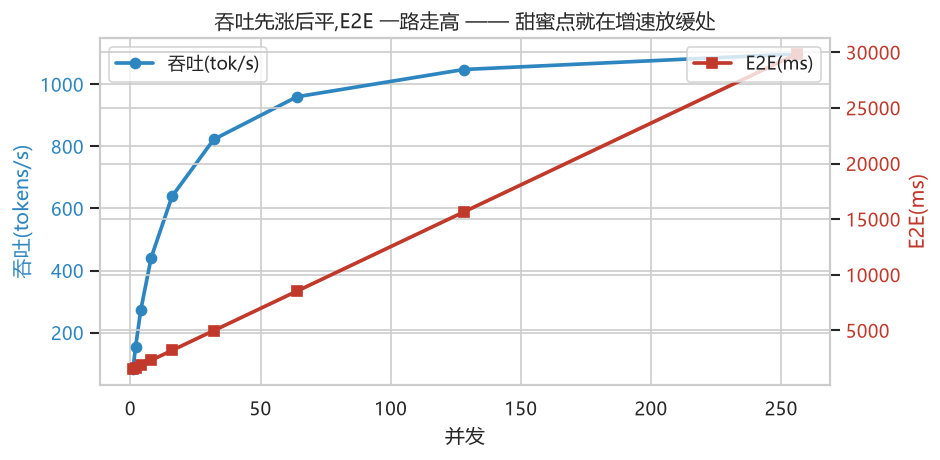

In [2]:
def sim_e2e(c, base_ttft=3.5, base_tpot=12.0, S=128, alpha=0.12):
    """多并发下的 E2E 模拟(单位 ms):并发越高,争抢越严重"""
    ttft = base_ttft * (1 + alpha * (c - 1))
    tpot = base_tpot * (1 + alpha * (c - 1) * 0.6)
    return ttft, tpot, ttft + S * tpot

rows = []
for c in [1, 2, 4, 8, 16, 32, 64, 128, 256]:
    ttft, tpot, e2e = sim_e2e(c)
    thr = c * 128 / e2e * 1000                      # tokens/s
    rows.append((c, ttft, e2e, thr))
    print(f"并发 {c:4d}: TTFT={ttft:6.1f}ms  E2E={e2e:8.1f}ms  吞吐={thr:9,.0f} tok/s")

cs = [r[0] for r in rows]; thrs = [r[3] for r in rows]; e2es = [r[2] for r in rows]
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(cs, thrs, "o-", color="#2e86c1", lw=2.2, label="吞吐(tok/s)")
ax1.set_xlabel("并发"); ax1.set_ylabel("吞吐(tokens/s)", color="#2e86c1")
ax1.tick_params(axis="y", labelcolor="#2e86c1")
ax2 = ax1.twinx()
ax2.plot(cs, e2es, "s-", color="#c0392b", lw=2.2, label="E2E(ms)")
ax2.set_ylabel("E2E(ms)", color="#c0392b"); ax2.tick_params(axis="y", labelcolor="#c0392b")
ax1.set_title("吞吐先涨后平,E2E 一路走高 —— 甜蜜点就在增速放缓处")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
plt.tight_layout()

## 3️⃣ 昇腾 profiling 工具:把『慢』照出来 🔦

GPU 上用 Nsight 系列,昇腾上用两件套:

1. **msprof**:命令行 profiling 工具,采集算子耗时、内存、通信等时间线;
2. **Ascend Insight Toolkit**(新版昇腾的配套分析工具):把 msprof 的采集数据可视化成
   瀑布图、热力图,定位瓶颈。

用法概览(真机):
```bash
msprof --output=prof_dir --application="./run_infer.sh"
```
分析思路与 GPU 完全一致:看哪个算子占时最长、搬移是否与计算重叠、kernel 是否被调度空转。
下面用 torch 模拟一次 profiling:把一次推理的算子按耗时拆成瀑布图:

🔦 瀑布图思维:profiling 的意义是『先找到占 80% 时间的那 20% 算子』,再决定融合 / 并行 / 量化。

瓶颈一眼看出:qkv 投影 + 两个 mlp 投影占大头 → 优化应聚焦矩阵乘(用 Cube/融合)。


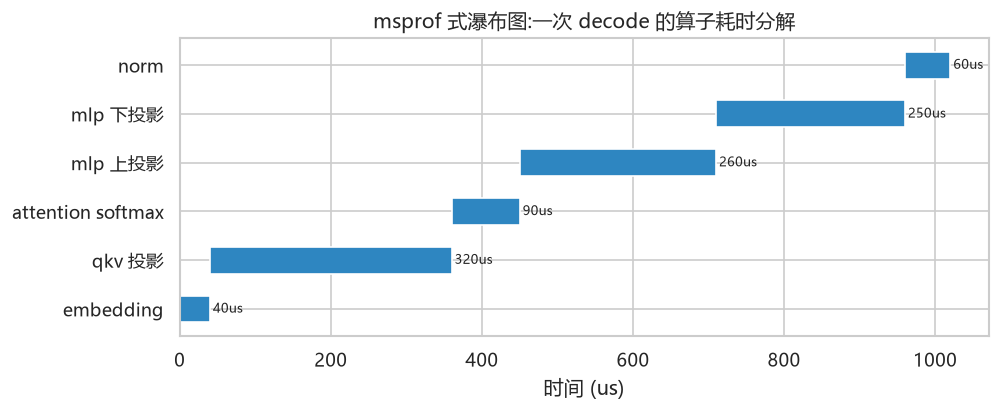

In [3]:
# 模拟 profiling:一次推理的算子时间线(单位 us,示意)
ops = [("embedding", 40, 5), ("qkv 投影", 320, 25), ("attention softmax", 90, 15),
       ("mlp 上投影", 260, 22), ("mlp 下投影", 250, 22), ("norm", 60, 10)]
fig, ax = plt.subplots(figsize=(8.5, 3.6))
base = 0.0
for i, (name, dur, y) in enumerate(ops):
    ax.barh(i, dur, left=base, height=0.55, color="#2e86c1")
    ax.text(base + dur + 4, i, f"{dur}us", va="center", fontsize=8)
    base += dur
ax.set_yticks(range(len(ops))); ax.set_yticklabels([o[0] for o in ops])
ax.set_xlabel("时间 (us)")
ax.set_title("msprof 式瀑布图:一次 decode 的算子耗时分解")
plt.tight_layout()
print("瓶颈一眼看出:qkv 投影 + 两个 mlp 投影占大头 → 优化应聚焦矩阵乘(用 Cube/融合)。")

## 4️⃣ 调优方法论:先量后改,逐项开关 🧭

昇腾推理调优的完整闭环(和 vLLM 上完全一致):

1. **跑基线**:先不动任何开关,量出 TTFT/TPOT/吞吐;
2. **上 profiler**:找到瓶颈算子;
3. **逐项开优化**:图模式(GRAPH)→ 算子融合 → 动态 shape → KV 量化 → 张量并行(TP),
   **每开一项就复测一次**,记录收益;
4. **定配置**:选『收益/风险』最优的组合固化。

关键纪律:**一次只动一个变量**。把"逐项开关的收益"画成瀑布图,一目了然:

📉 瀑布图:每一项优化的收益不同,叠加起来相当可观 —— 但要实测确认,别全信示意数字。

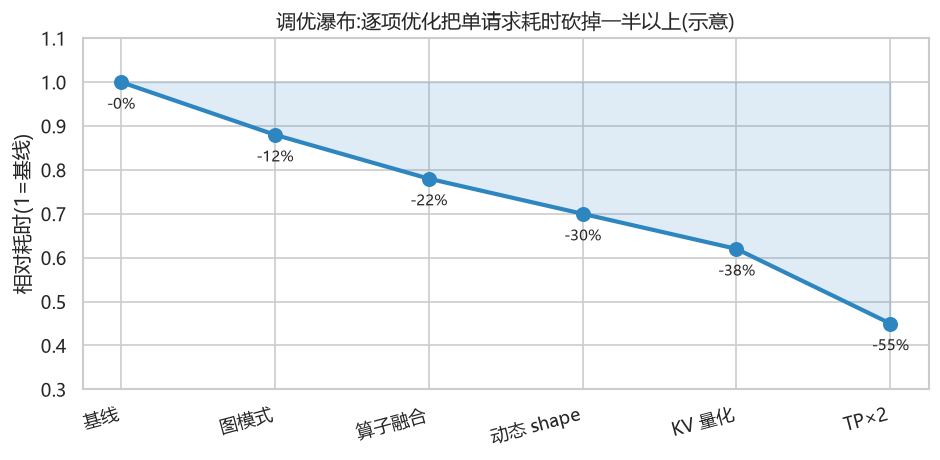

In [4]:
steps = ["基线", "图模式", "算子融合", "动态 shape", "KV 量化", "TP×2"]
t_rel = [1.00, 0.88, 0.78, 0.70, 0.62, 0.45]       # 相对耗时(示意)
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(steps))
ax.plot(x, t_rel, "o-", color="#2e86c1", lw=2.5, ms=8)
ax.fill_between(x, t_rel, 1.0, color="#2e86c1", alpha=0.15)
for i, (xi, v) in enumerate(zip(x, t_rel)):
    ax.annotate(f"{-100*(1-v):.0f}%", (xi, v), textcoords="offset points",
                xytext=(0, -16), ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(steps, rotation=15, ha="right")
ax.set_ylim(0.3, 1.1); ax.set_ylabel("相对耗时(1=基线)")
ax.set_title("调优瀑布:逐项优化把单请求耗时砍掉一半以上(示意)")
plt.tight_layout()

## 5️⃣ vLLM ↔ 昇腾:调优参数对照表 ⚖️

你在 GPU 上会调的 vLLM 参数,昇腾上几乎都有对应:

| vLLM(GPU) | 昇腾 / MindIE / vLLM-Ascend | 作用 |
|---|---|---|
| `--gpu-memory-utilization` | `--memory-fraction` 等 | 显存/内存使用率,留给 KV |
| `--max-num-seqs` | 并发数 / batch 上限 | 控制同时处理的请求数 |
| `--tensor-parallel-size` | `--tensor-parallel-size` | 张量并行卡数(HCCL) |
| `--kv-cache-dtype` | KV 量化(W8A8/FP8) | KV 显存减半 |
| `--enable-prefix-caching` | 前缀缓存 | 公共前缀复用 |
| `--enforce-eager` | GRAPH/PNATIVE 模式 | eager(逐算子)vs 图模式 |

📊 对照热力图:调参的思路完全通用 —— 你在第 48-50 课练过的那套 vLLM 调优,换到昇腾只需换个参数名。

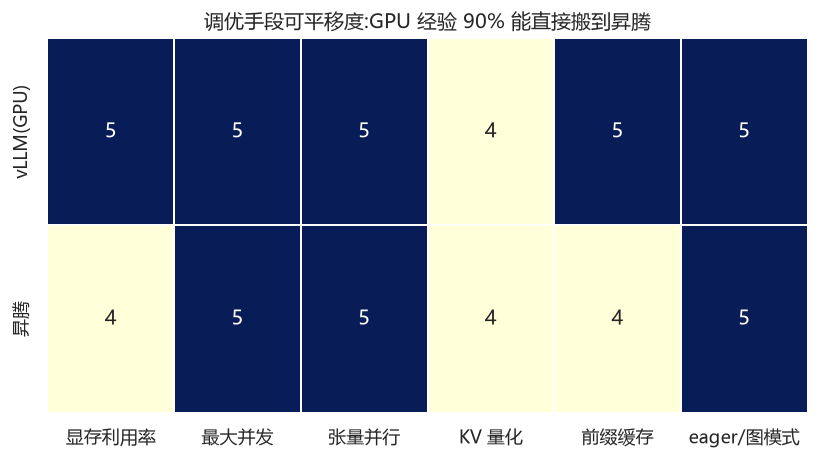

In [5]:
rows = ["显存利用率", "最大并发", "张量并行", "KV 量化", "前缀缓存", "eager/图模式"]
gpu = [5, 5, 5, 4, 5, 5]
asc = [4, 5, 5, 4, 4, 5]
df = pd.DataFrame({"vLLM(GPU)": gpu, "昇腾": asc}, index=rows)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(df.T, annot=True, fmt="d", cmap="YlGnBu", linewidths=1, linecolor="white",
            cbar=False, ax=ax)
ax.set_title("调优手段可平移度:GPU 经验 90% 能直接搬到昇腾")
plt.tight_layout()

## 6️⃣ 配套 App:性能仪表盘 🎛️

运行同目录的 `app_99_ascend_perf.py`,**拖并发与输出长度、切优化等级与设备**,
实时看 TTFT/TPOT/吞吐、吞吐曲线、延迟组成饼图与调优瀑布:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_99_ascend_perf.py
```

浏览器打开 **http://localhost:8501**(也可 `--server.port 8699`)。完整源码如下:

📜 运行本 cell 会覆盖写入 `app_99_ascend_perf.py`,保证 notebook 与 app 始终一致。

In [6]:
%%writefile app_99_ascend_perf.py
# -*- coding: utf-8 -*-
# app_99_ascend_perf.py — 昇腾推理性能调优仪表盘 📊
import streamlit as st
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="昇腾推理性能调优 📊", layout="wide")
st.title("📊 第 99 课 · 昇腾推理性能调优:吞吐 / 时延仪表盘")

st.markdown("""
性能调优盯三个数:**TTFT(首字延迟)、TPOT(每字延迟)、吞吐(tokens/s)**。
下面拖一拖并发与输出长度、开一开优化开关,实时看指标怎么变 —— 就像第 50 课的仪表盘,
这次是昇腾版。
""")

st.sidebar.header("🎛️ 参数")
conc = st.sidebar.slider("并发请求数", 1, 256, 32, 1)
out_len = st.sidebar.slider("输出 token 数", 16, 1024, 128, 16)
opt_level = st.sidebar.radio("优化等级", ["baseline(全关)", "图模式+融合", "全部(KV量化+动态shape+TP)"])
npu = st.sidebar.selectbox("设备", ["昇腾 910B", "昇腾 310P", "RTX 5060(GPU 对照)"])
st.sidebar.caption("优化等级越高,单请求越快,但基线吞吐越低 —— 需要实测选甜蜜点。")

BASE = {"昇腾 910B": (3.5, 12.0), "昇腾 310P": (7.0, 25.0), "RTX 5060(GPU 对照)": (4.5, 16.0)}
base_ttft, base_tpot = BASE[npu]
alpha = 0.12                                  # 争抢系数
opt_scale = {"baseline(全关)": 1.0, "图模式+融合": 0.75, "全部(KV量化+动态shape+TP)": 0.55}
scale = opt_scale[opt_level]

ttft = base_ttft * (1 + alpha * (conc - 1)) * scale
tpot = base_tpot * (1 + alpha * (conc - 1) * 0.6) * scale
e2e = ttft + out_len * tpot
thr = conc * out_len / e2e

c1, c2, c3, c4 = st.columns(4)
c1.metric("TTFT(首字延迟)", f"{ttft:.1f} ms")
c2.metric("TPOT(每字延迟)", f"{tpot:.2f} ms")
c3.metric("E2E(端到端)", f"{e2e/1000:.2f} s")
c4.metric("吞吐", f"{thr:,.0f} tokens/s")

st.subheader("📈 吞吐 vs 并发(甜蜜点)")
cs = np.arange(1, 257)
thrs = []
for c in cs:
    t_ttft = base_ttft * (1 + alpha * (c - 1)) * scale
    t_tpot = base_tpot * (1 + alpha * (c - 1) * 0.6) * scale
    thrs.append(c * out_len / (t_ttft + out_len * t_tpot))
fig = go.Figure()
fig.add_trace(go.Scatter(x=cs, y=thrs, mode="lines", name="吞吐",
                         line=dict(color="#2e86c1", width=3)))
fig.add_vline(x=conc, line_dash="dash", line_color="#888")
fig.update_layout(title=f"吞吐曲线({npu} · {opt_level})", xaxis_title="并发",
                  yaxis_title="吞吐(tokens/s)", height=340,
                  margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig, use_container_width=True)

st.subheader("🥧 单请求延迟组成")
fig2 = go.Figure(go.Pie(labels=["Prefill(TTFT)", "Decode(输出×TPOT)", "排队/调度"],
                        values=[ttft, out_len * tpot * 0.97, out_len * tpot * 0.03],
                        hole=0.5, marker_colors=["#e74c3c", "#2e86c1", "#95a5a6"]))
fig2.update_layout(title="E2E 延迟构成:输出越长,Decode 越占大头", height=320,
                   margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig2, use_container_width=True)

st.subheader("🛠️ 优化收益瀑布(相对 baseline)")
levels = ["baseline", "+图模式/融合", "+动态shape", "+KV量化", "+TP并行"]
ratio = [1.0, 0.8, 0.68, 0.55, 0.42]
fig3 = go.Figure(go.Waterfall(x=levels, y=[ratio[0]] + [ratio[i]-ratio[i-1] for i in range(1, 5)],
                              measure=["absolute"] + ["relative"]*4,
                              decreasing=dict(marker_color="#27ae60"),
                              connector=dict(line=dict(color="#888"))))
fig3.update_layout(title="调优瀑布:每步优化把单请求耗时再砍一截(示意)", yaxis_title="相对耗时",
                   height=320, margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig3, use_container_width=True)

st.markdown("""
> 💡 **结论**:调优第一步永远是**上 profiler 量**(昇腾用 msprof / Ascend Insight Toolkit),
> 分清瓶颈是『算得慢 / 搬得等 / 调度空转』;然后按 图模式→融合→动态shape→KV 量化→并行 的
> 顺序逐项开,每开一项复测一次,别一口气全开。
""")

Overwriting app_99_ascend_perf.py


## ✅ 本课小结

- 三大指标:TTFT(prefill)、TPOT(decode)、吞吐(tokens/s),E2E = TTFT + S×TPOT
- 昇腾 profiling:msprof 采集 + Ascend Insight Toolkit 可视化,和 Nsight 一个套路
- 调优闭环:跑基线 → 上 profiler → 逐项开优化 → 复测记录 → 固化配置
- 优化菜单:图模式、算子融合、动态 shape、KV 量化、张量并行 —— 一次只动一个
- vLLM(GPU)的调优参数在昇腾/MindIE 上几乎一一对应,经验可平移

## ✍️ 动手练习

1. 把第 2 节的 alpha 改成 0.05,观察甜蜜点位置如何右移
2. 给第 3 节瀑布图加一个『融合后』版本,对比总时长
3. 在真机(或 HiDevLab 昇腾云)上跑一次 msprof,导出分析结果并截图
4. 对照第 5 节表格,把 vLLM-Ascend 的启动参数写成一份自己的『调优清单』

## 🔗 延伸阅读

- [昇腾性能分析工具文档](https://www.hiascend.com/document)
- [MindIE 推理引擎](https://www.hiascend.com/software/mindie)
- [vLLM 性能指南(对照)](https://docs.vllm.ai/en/latest/performance/overview.html)
- [vLLM-Ascend](https://github.com/vllm-project/vllm-ascend)

---
> 🎉 恭喜完成本课!下一课见!